# Laminar resting-state gradients demo

This notebook reproduces the core analysis of the paper on a precomputed subject-averaged multilaminar
functional-connectivity (FC) matrix using the **Schaefer-400** parcellation.

The two helper modules (`gradients.py`, `surface_maps.py`) sit next to this
notebook and are simplified, Schaefer-only versions of the full pipeline.

## 1. Setup

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from gradients import run_gradient_analysis_auto, inter_areal_dissimilarity
from surface_maps import plotSurfaceMap

In [2]:
# ----------------- Parameters -----------------
N = 400                       # Schaefer-400 parcels per layer

DEMO_DIR = Path.cwd()         # this notebook's folder
FC_PATH = DEMO_DIR / "FC_matrix.npy"
OUTPUT_DIR = DEMO_DIR / "results"
OUTPUT_DIR.mkdir(exist_ok=True)

# Atlas directory
SCHAEFER_DIR = "SchaeferAtlas"
SURF_DIR = "SchaeferAtlas"

## 2. Load the FC matrix

`FC_matrix.npy` is a precomputed multiplex adjacency matrix of shape
`(L*N, L*N)`, where `L` is the number of laminar depths and `N = 400`.

Loaded FC_matrix.npy  shape=(1200, 1200)
  min=-0.3623  max=1.0000
  inferred layers L = 3


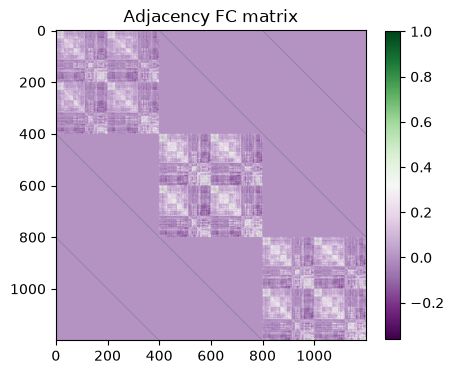

In [3]:
M = np.load(FC_PATH, allow_pickle=False)
print(f"Loaded {FC_PATH.name}  shape={M.shape}")
print(f"  min={M.min():.4f}  max={M.max():.4f}")

n_layers = M.shape[0] // N
print(f"  inferred layers L = {n_layers}")

plt.figure(figsize=(5, 5))
plt.imshow(M, cmap="PRGn")
plt.title("Adjacency FC matrix")
plt.colorbar(shrink=0.8)
plt.show()

## 3. Gradient analysis

We fit up to `max_components` diffusion-map gradients with a cosine kernel and
keep the fewest components that together explain `var_threshold` of the
normalised spectrum. A scree plot is written to the results folder.

In [4]:
G, eig, all_l, frac, cum, n_keep = run_gradient_analysis_auto(
    M,
    outputDir=str(OUTPUT_DIR),
    max_components=50,
    kernel="cosine",
    approach="dm",
    var_threshold=0.85,
)
print(f"Kept {n_keep} gradients (>= 85% of the normalised spectrum)")
print(f"Gradient array shape: {G.shape}  ->  ({n_layers} layers x {N} parcels, {n_keep} components)")

Kept 15 gradients (>= 85% of the normalised spectrum)
Gradient array shape: (1200, 15)  ->  (3 layers x 400 parcels, 15 components)


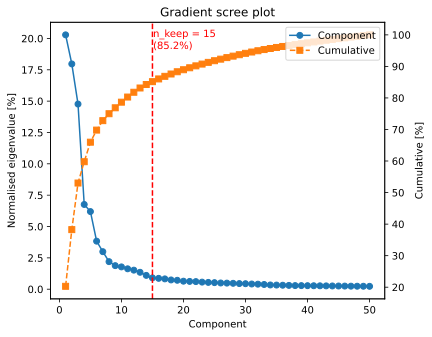

In [5]:
# Show the scree plot inline
from IPython.display import SVG, display
display(SVG(filename=str(OUTPUT_DIR / "GradientScree.svg")))

## 4. Inter-areal laminar dissimilarity

For each parcel we concatenate its gradient coordinates across layers into a
single laminar profile, then compute the mean cosine distance to every other
parcel. We get an overall map plus deep / middle / superficial layer-specific
maps.

In [6]:
D_inter, D_inter_deep, D_inter_mid, D_inter_sup, D = inter_areal_dissimilarity(
    G, str(OUTPUT_DIR), N=N
)

for name, arr in [
    ("overall", D_inter),
    ("deep", D_inter_deep),
    ("middle", D_inter_mid),
    ("superficial", D_inter_sup),
]:
    print(f"{name:>12}: min={arr.min():.4f}  max={arr.max():.4f}")

     overall: min=0.9528  max=1.0416
        deep: min=0.9467  max=1.0601
      middle: min=0.9623  max=1.0410
 superficial: min=0.9479  max=1.0497


## 5. Surface maps

Finally we project the parcelwise dissimilarity onto the cortical surface. Each
figure is returned and displayed inline (and also saved to `results/`).

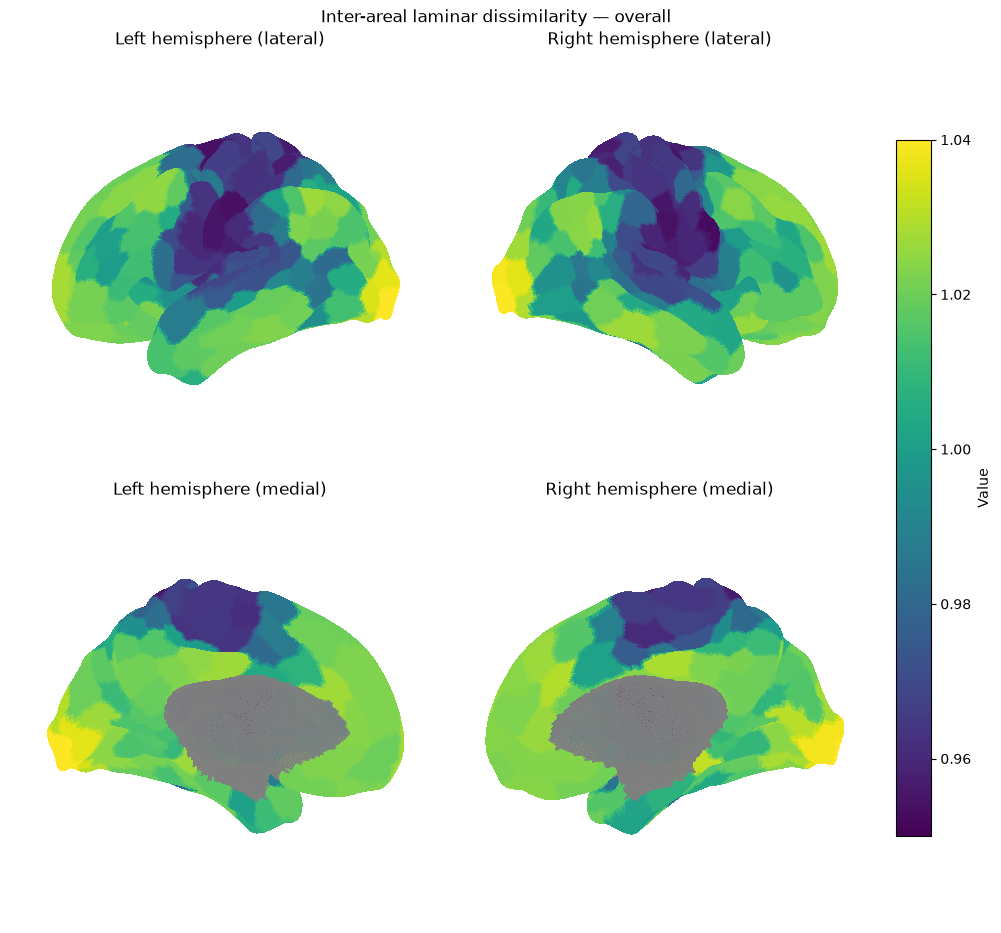

In [7]:
fig = plotSurfaceMap(
    D_inter, str(OUTPUT_DIR), "SurfaceMap_inter.png",
    vmin=0.95, vmax=1.04, cmap="viridis",
    schaefer_dir=SCHAEFER_DIR, surf_dir=SURF_DIR,
)
fig.suptitle("Inter-areal laminar dissimilarity — across layers", y=1.02)
plt.show()

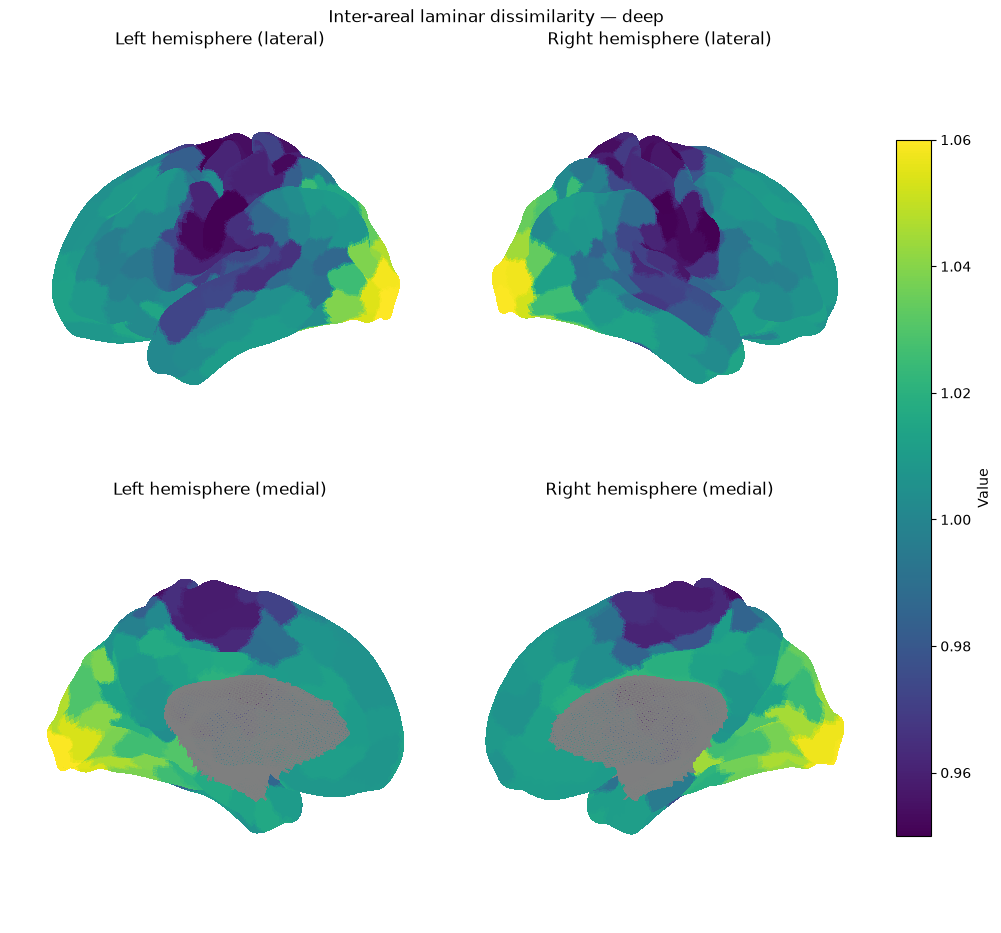

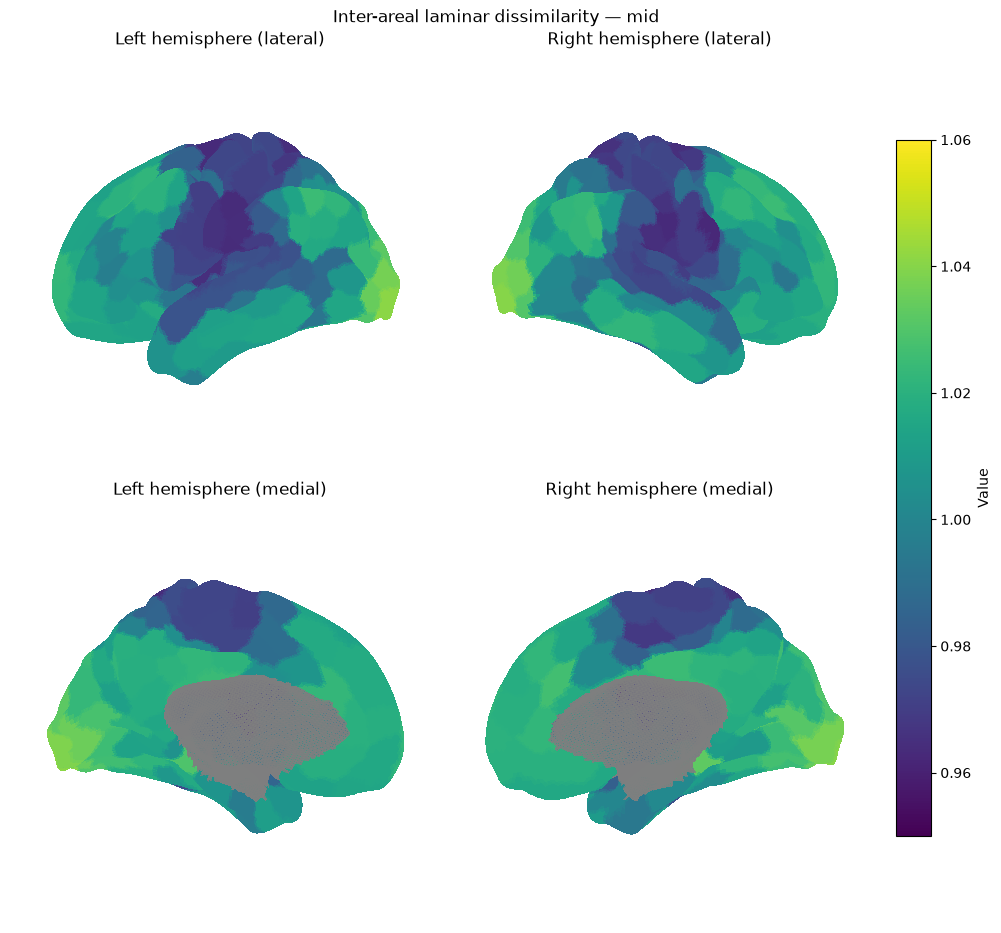

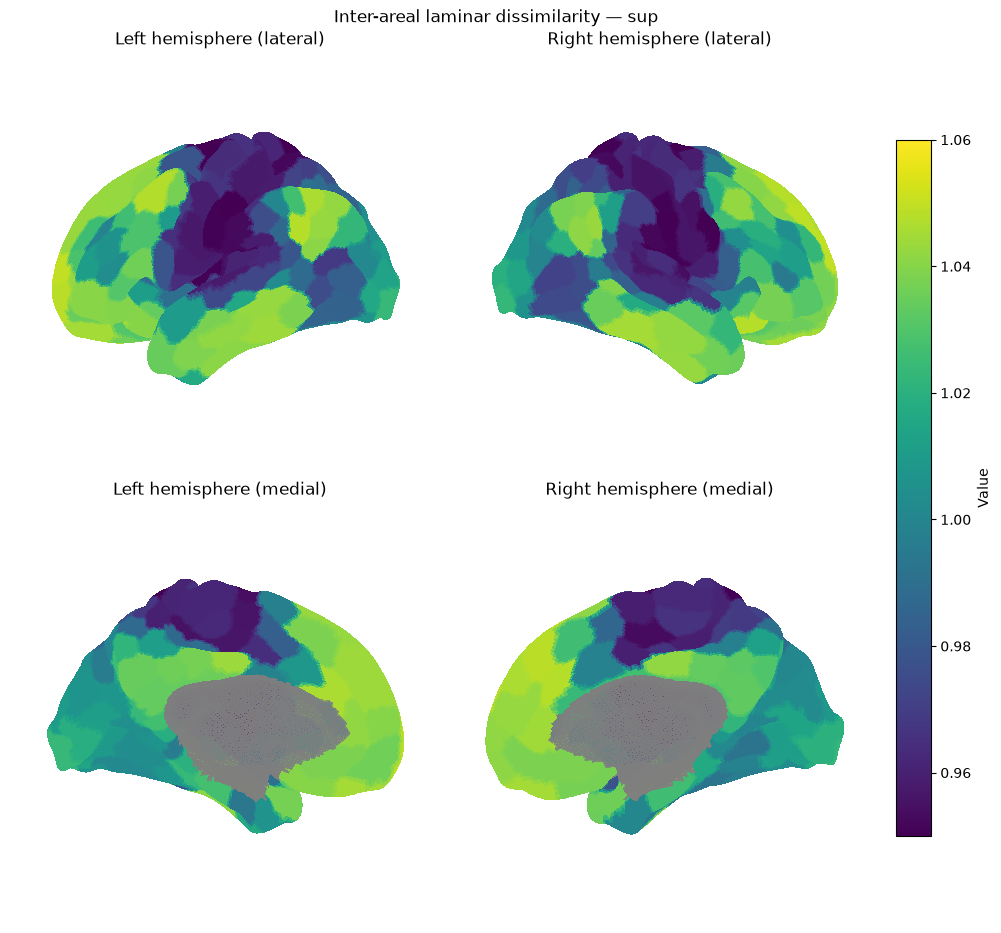

In [8]:
for label, arr in [
    ("deep", D_inter_deep),
    ("mid", D_inter_mid),
    ("sup", D_inter_sup),
]:
    fig = plotSurfaceMap(
        arr, str(OUTPUT_DIR), f"SurfaceMap_inter_{label}.png",
        vmin=0.95, vmax=1.06, cmap="viridis",
        schaefer_dir=SCHAEFER_DIR, surf_dir=SURF_DIR,
    )
    fig.suptitle(f"Inter-areal laminar dissimilarity — {label}", y=1.02)
    plt.show()